# Gold Price Prediction using Random Forest Regressor
### Predicting Tomorrow's Gold Closing Price

**Core strategy:** Predict the daily price change (`Close_tomorrow - Close_today`) and reconstruct tomorrow's absolute close price:

`predicted_tomorrow_close = today_close + predicted_change`

This design is more robust than directly predicting absolute prices for tree-based models when market price levels shift over time.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42

## 1. Load and Explore Data

In [7]:
df = pd.read_csv('../../data/Gold_Market_10y.csv')

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Close price range: ${df['Close'].min():.2f} to ${df['Close'].max():.2f}")

df.head()

Dataset shape: (2511, 16)
Date range: 2016-01-29 to 2026-01-23
Close price range: $106.95 to $458.00


,Date,Close,High,Low,Open,Volume,Adj Close,Daily_Return,MA_20,MA_50,MA_200,Volatility_20,Year,Month,Day_of_Week,Quarter
0,2016-01-29,106.949997,107.000000,106.260002,106.610001,8098700,106.949997,NaN,NaN,NaN,NaN,NaN,2016,1,4,1
1,2016-02-01,108.050003,108.150002,107.529999,107.540001,10471800,108.050003,1.028524,NaN,NaN,NaN,NaN,2016,2,0,1
2,2016-02-02,108.089996,108.180000,107.349998,107.919998,6656000,108.089996,0.037014,NaN,NaN,NaN,NaN,2016,2,1,1
3,2016-02-03,109.250000,109.580002,107.900002,107.910004,15785200,109.250000,1.073183,NaN,NaN,NaN,NaN,2016,2,2,1
4,2016-02-04,110.570000,110.699997,109.919998,110.449997,13213700,110.570000,1.208238,NaN,NaN,NaN,NaN,2016,2,3,1


In [8]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Date               0
Close              0
High               0
Low                0
Open               0
Volume             0
Adj Close          0
Daily_Return       1
MA_20             19
MA_50             49
MA_200           199
Volatility_20     20
Year               0
Month              0
Day_of_Week        0
Quarter            0
dtype: int64


## 2. Data Cleaning
Drop rows with NaN values in rolling indicators to avoid leaking fabricated values into training.

In [9]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape after initial cleaning: {df.shape}')
print(f'Total remaining missing values: {int(df.isnull().sum().sum())}')

Dataset shape after initial cleaning: (2312, 16)
Total remaining missing values: 0


## 3. Feature Engineering
Create lag, momentum, volatility, and technical-indicator features to better capture market behavior.

In [10]:
# Lag features
for lag in [1, 2, 3, 5]:
    df[f'Close_lag_{lag}'] = df['Close'].shift(lag)

# Returns and momentum
df['Return_1d'] = df['Close'].pct_change(1) * 100
df['Return_2d'] = df['Close'].pct_change(2) * 100
df['Return_5d'] = df['Close'].pct_change(5) * 100
df['Return_10d'] = df['Close'].pct_change(10) * 100

# RSI (14)
delta = df['Close'].diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# MACD
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_12'] - df['EMA_26']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['MACD_hist'] = df['MACD'] - df['MACD_signal']

# Bollinger Band width
bb_std = df['Close'].rolling(20).std()
df['BB_width'] = (2 * bb_std) / df['MA_20'] * 100

# Intraday / liquidity style features
df['HL_spread_pct'] = (df['High'] - df['Low']) / df['Close'] * 100
df['OC_change_pct'] = (df['Close'] - df['Open']) / df['Open'] * 100
df['Volume_change'] = df['Volume'].pct_change() * 100

# Distance from moving averages
df['Dist_MA20_pct'] = (df['Close'] - df['MA_20']) / df['MA_20'] * 100
df['Dist_MA50_pct'] = (df['Close'] - df['MA_50']) / df['MA_50'] * 100
df['Dist_MA200_pct'] = (df['Close'] - df['MA_200']) / df['MA_200'] * 100

# Remove temporary EMA columns used for MACD construction
df.drop(columns=['EMA_12', 'EMA_26'], inplace=True)

# Drop rows introduced as NaN by rolling/lag computations
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape after feature engineering: {df.shape}')

Dataset shape after feature engineering: (2293, 35)


## 4. Target Construction
Target is next-day price change. We also keep the true next-day close for final absolute-price evaluation.

In [11]:
df['Price_Change'] = df['Close'].shift(-1) - df['Close']
df['Tomorrow_Close'] = df['Close'].shift(-1)

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Final modeling dataset shape: {df.shape}')
print(df[['Close', 'Price_Change', 'Tomorrow_Close']].head())

Final modeling dataset shape: (2292, 37)
        Close  Price_Change  Tomorrow_Close
0  111.570000     -1.169998      110.400002
1  110.400002      0.419998      110.820000
2  110.820000     -0.370003      110.449997
3  110.449997     -1.619995      108.830002
4  108.830002     -1.490005      107.339996


## 5. Feature Selection and Time-Series Split

In [12]:
feature_columns = [
    'Close', 'High', 'Low', 'Open', 'Volume',
    'Daily_Return', 'Volatility_20',
    'Year', 'Month', 'Day_of_Week', 'Quarter',
    'Close_lag_1', 'Close_lag_2', 'Close_lag_3', 'Close_lag_5',
    'Return_1d', 'Return_2d', 'Return_5d', 'Return_10d',
    'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_width',
    'HL_spread_pct', 'OC_change_pct', 'Volume_change',
    'Dist_MA20_pct', 'Dist_MA50_pct', 'Dist_MA200_pct'
]

X = df[feature_columns]
y = df['Price_Change']

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

close_train = df['Close'].iloc[:split_index]
close_test = df['Close'].iloc[split_index:]
tomorrow_close_train = df['Tomorrow_Close'].iloc[:split_index]
tomorrow_close_test = df['Tomorrow_Close'].iloc[split_index:]

print(f'Features used: {len(feature_columns)}')
print(f'Train set: {X_train.shape[0]} rows')
print(f'Test set:  {X_test.shape[0]} rows')

Features used: 30
Train set: 1833 rows
Test set:  459 rows


## 6. Hyperparameter Tuning (GridSearchCV + TimeSeriesSplit)
`quick_mode=True` helps when testing quickly. Set `quick_mode=False` before final report to run a broader search.

In [14]:
quick_mode = True  # Set False for final report-quality tuning

if quick_mode:
    param_grid = {
        'n_estimators': [200, 400],
        'max_depth': [12, 20, None],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt']
    }
else:
    param_grid = {
        'n_estimators': [200, 400, 700, 1000],
        'max_depth': [12, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.5]
    }

# Use conservative parallelism to avoid worker crashes on Windows memory limits
rf = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=1,
    oob_score=True,
    bootstrap=True
)

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=1,
    verbose=1
)

total_combos = 1
for values in param_grid.values():
    total_combos *= len(values)

print(f'Total combinations: {total_combos}')
print('Training + tuning in progress...')
grid_search.fit(X_train, y_train)

print('Best parameters found:')
print(grid_search.best_params_)
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")

Total combinations: 24
Training + tuning in progress...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:
{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}
Best CV MAE: 1.2533


## 7. Final Model, Predictions, and Price Reconstruction

In [15]:
best_model = grid_search.best_estimator_

pred_change_train = best_model.predict(X_train)
pred_change_test = best_model.predict(X_test)

pred_price_train = close_train.values + pred_change_train
pred_price_test = close_test.values + pred_change_test

print('Model training complete.')
if hasattr(best_model, 'oob_score_'):
    print(f"OOB score: {best_model.oob_score_:.6f}")

Model training complete.
OOB score: -0.042801


## 8. Evaluation

In [16]:
def evaluate_model(y_true, y_pred, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100

    print(f'--- {label} ---')
    print(f'MAE:  {mae:.4f}')
    print(f'MSE:  {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'R2:   {r2:.6f}')
    print(f'MAPE: {mape:.4f}%')
    print()

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print('=' * 65)
print('PRICE CHANGE PREDICTION METRICS')
print('=' * 65)
change_train_metrics = evaluate_model(y_train.values, pred_change_train, 'Train - Price Change')
change_test_metrics = evaluate_model(y_test.values, pred_change_test, 'Test - Price Change')

print('=' * 65)
print('RECONSTRUCTED ABSOLUTE PRICE METRICS')
print('=' * 65)
price_train_metrics = evaluate_model(tomorrow_close_train.values, pred_price_train, 'Train - Absolute Price')
price_test_metrics = evaluate_model(tomorrow_close_test.values, pred_price_test, 'Test - Absolute Price')

PRICE CHANGE PREDICTION METRICS
--- Train - Price Change ---
MAE:  0.8333
MSE:  1.2960
RMSE: 1.1384
R2:   0.309071
MAPE: 2291923.1429%

--- Test - Price Change ---
MAE:  2.6982
MSE:  14.6138
RMSE: 3.8228
R2:   -0.098572
MAPE: 155.4429%

RECONSTRUCTED ABSOLUTE PRICE METRICS
--- Train - Absolute Price ---
MAE:  0.8333
MSE:  1.2960
RMSE: 1.1384
R2:   0.998071
MAPE: 0.5420%

--- Test - Absolute Price ---
MAE:  2.6982
MSE:  14.6138
RMSE: 3.8228
R2:   0.995997
MAPE: 0.9203%



## 9. Visualizations and Saved Figure

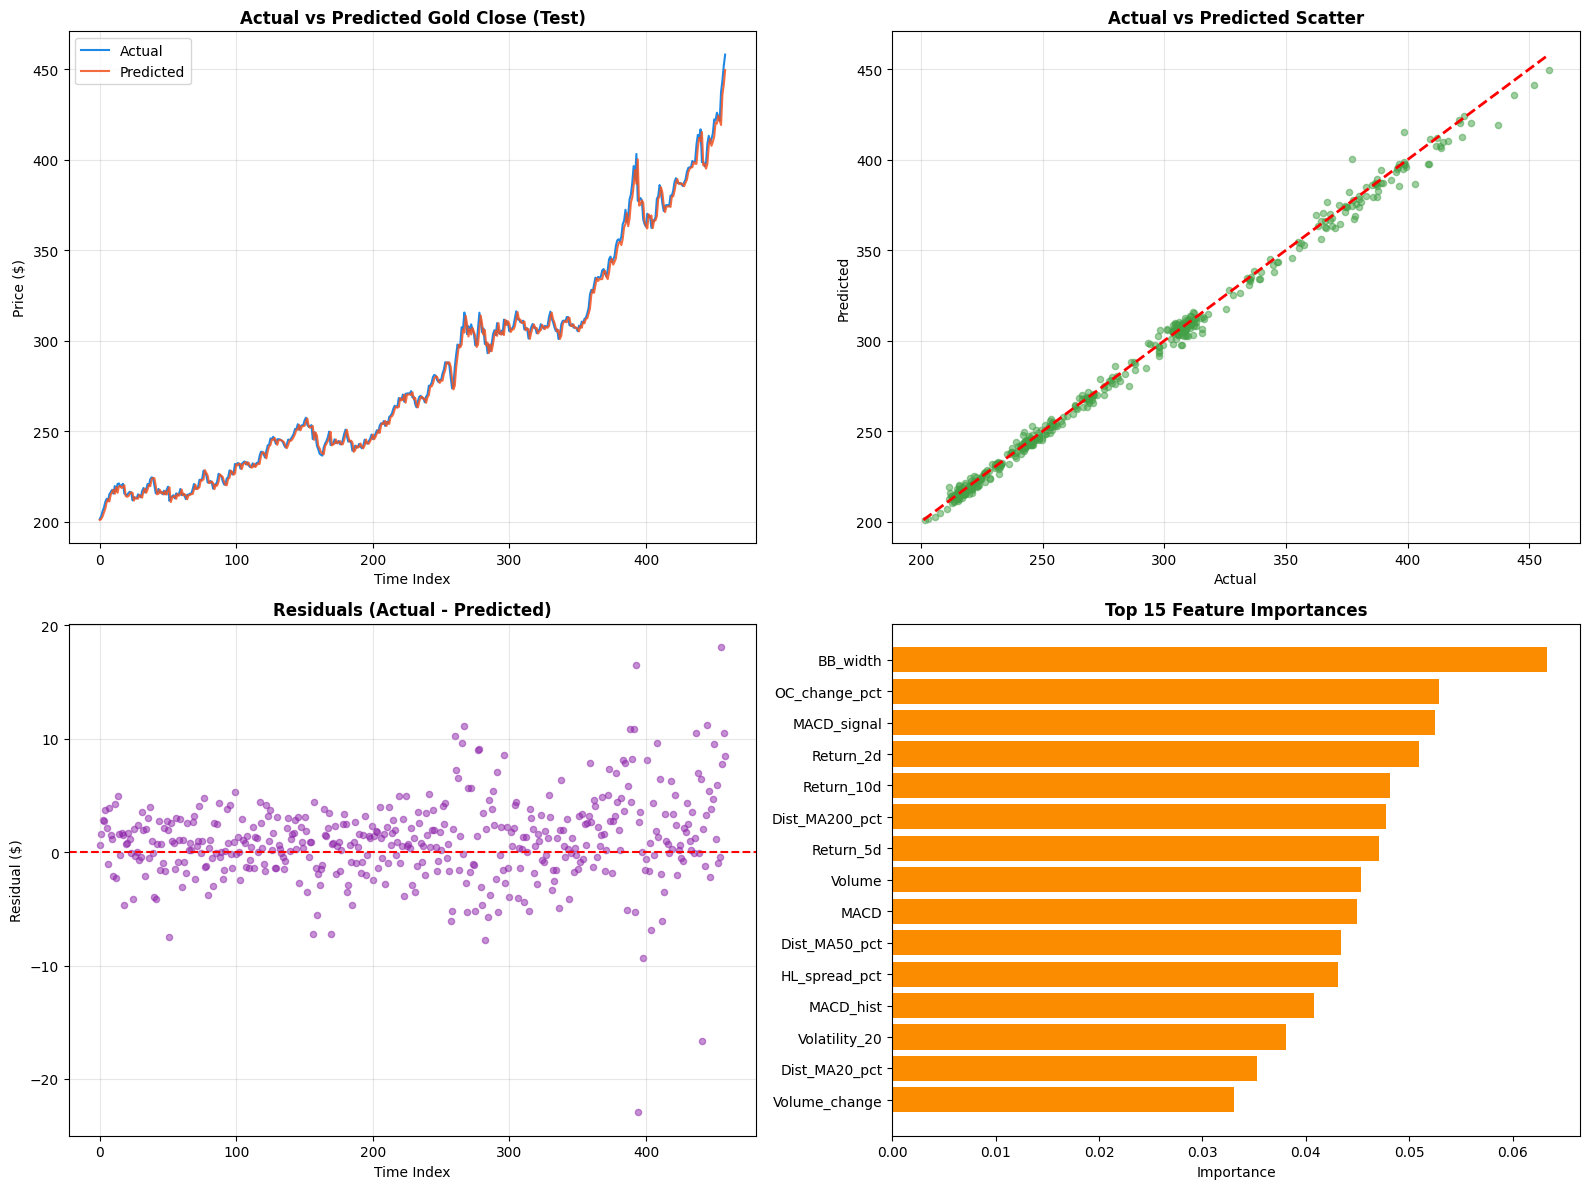

Saved figure: ../../reports/figures/random_forest_results.png


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Actual vs predicted on test set
axes[0, 0].plot(tomorrow_close_test.values, label='Actual', linewidth=1.5, color='#1e88e5')
axes[0, 0].plot(pred_price_test, label='Predicted', linewidth=1.5, color='#f4511e', alpha=0.85)
axes[0, 0].set_title('Actual vs Predicted Gold Close (Test)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time Index')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2) Scatter actual vs predicted
axes[0, 1].scatter(tomorrow_close_test.values, pred_price_test, alpha=0.5, s=20, color='#43a047')
min_v = min(tomorrow_close_test.min(), pred_price_test.min())
max_v = max(tomorrow_close_test.max(), pred_price_test.max())
axes[0, 1].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2)
axes[0, 1].set_title('Actual vs Predicted Scatter', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')
axes[0, 1].grid(alpha=0.3)

# 3) Residuals
residuals = tomorrow_close_test.values - pred_price_test
axes[1, 0].scatter(range(len(residuals)), residuals, alpha=0.5, s=20, color='#8e24aa')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Time Index')
axes[1, 0].set_ylabel('Residual ($)')
axes[1, 0].grid(alpha=0.3)

# 4) Top feature importance
feature_importance = pd.Series(best_model.feature_importances_, index=feature_columns)
top_features = feature_importance.nlargest(15).sort_values(ascending=True)
axes[1, 1].barh(top_features.index, top_features.values, color='#fb8c00')
axes[1, 1].set_title('Top 15 Feature Importances', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../../reports/figures/random_forest_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('Saved figure: ../../reports/figures/random_forest_results.png')

## 10. Save Prediction Outputs

In [22]:
test_results = pd.DataFrame({
    'Date': df['Date'].iloc[split_index:].values,
    'Today_Close': close_test.values,
    'Actual_Tomorrow_Close': tomorrow_close_test.values,
    'Predicted_Tomorrow_Close': pred_price_test,
    'Predicted_Change': pred_change_test,
    'Actual_Change': y_test.values
})

test_results['Absolute_Error'] = np.abs(test_results['Actual_Tomorrow_Close'] - test_results['Predicted_Tomorrow_Close'])
test_results['APE_pct'] = np.abs((test_results['Actual_Tomorrow_Close'] - test_results['Predicted_Tomorrow_Close']) / np.where(test_results['Actual_Tomorrow_Close'] == 0, 1e-8, test_results['Actual_Tomorrow_Close'])) * 100

test_results.to_csv('../../outputs/random_forest/test_predictions_random_forest.csv', index=False)

feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)
feature_importance_df.to_csv('../../outputs/random_forest/random_forest_feature_importance.csv', index=False)

print('Saved: ../../outputs/random_forest/test_predictions_random_forest.csv')
print('Saved: ../../outputs/random_forest/random_forest_feature_importance.csv')
test_results.head()

Saved: ../../outputs/random_forest/test_predictions_random_forest.csv
Saved: ../../outputs/random_forest/random_forest_feature_importance.csv


,Date,Today_Close,Actual_Tomorrow_Close,Predicted_Tomorrow_Close,Predicted_Change,Actual_Change,Absolute_Error,APE_pct
0,2024-03-25,200.990005,201.639999,201.053598,0.063592,0.649994,0.586402,0.290816
1,2024-03-26,201.639999,203.100006,201.525426,-0.114573,1.460007,1.574580,0.775273
2,2024-03-27,203.100006,205.720001,202.923221,-0.176785,2.619995,2.796780,1.359508
3,2024-03-28,205.720001,207.820007,205.067003,-0.652998,2.100006,2.753004,1.324706
4,2024-04-01,207.820007,210.889999,207.185481,-0.634526,3.069992,3.704518,1.756612


## 11. Predict Next Trading Day

In [19]:
last_row = X.iloc[-1:]
today_close = df['Close'].iloc[-1]

predicted_change = best_model.predict(last_row)[0]
predicted_tomorrow_close = today_close + predicted_change
predicted_pct_change = (predicted_change / today_close) * 100

print(f"Today's Close:                 ${today_close:.2f}")
print(f"Predicted Daily Change:        ${predicted_change:+.2f}")
print(f"Predicted Tomorrow Close:      ${predicted_tomorrow_close:.2f}")
print(f"Predicted Percent Change:      {predicted_pct_change:+.2f}%")

Today's Close:                 $451.79
Predicted Daily Change:        $-2.31
Predicted Tomorrow Close:      $449.48
Predicted Percent Change:      -0.51%


## 12. Final Summary and Comparison Template

In [20]:
print('=' * 70)
print('RANDOM FOREST PERFORMANCE SUMMARY')
print('=' * 70)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test R2 (Absolute Price):  {price_test_metrics['R2']:.6f}")
print(f"Test MAE (Absolute Price): ${price_test_metrics['MAE']:.4f}")
print(f"Test RMSE (Absolute Price): ${price_test_metrics['RMSE']:.4f}")
print(f"Test MAPE (Absolute Price): {price_test_metrics['MAPE']:.4f}%")
if hasattr(best_model, 'oob_score_'):
    print(f"OOB Score: {best_model.oob_score_:.6f}")
print('=' * 70)

comparison_template = pd.DataFrame([
    {'Model': 'Linear Regression', 'Test_R2': np.nan, 'Test_MAE': np.nan, 'Test_RMSE': np.nan},
    {'Model': 'Gradient Boosting', 'Test_R2': np.nan, 'Test_MAE': np.nan, 'Test_RMSE': np.nan},
    {'Model': 'Random Forest', 'Test_R2': price_test_metrics['R2'], 'Test_MAE': price_test_metrics['MAE'], 'Test_RMSE': price_test_metrics['RMSE']},
    {'Model': 'SVR', 'Test_R2': np.nan, 'Test_MAE': np.nan, 'Test_RMSE': np.nan}
])

print('\nFill this table after collecting other model metrics:')
comparison_template

RANDOM FOREST PERFORMANCE SUMMARY
Best Parameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 400}
Test R2 (Absolute Price):  0.995997
Test MAE (Absolute Price): $2.6982
Test RMSE (Absolute Price): $3.8228
Test MAPE (Absolute Price): 0.9203%
OOB Score: -0.042801

Fill this table after collecting other model metrics:


,Model,Test_R2,Test_MAE,Test_RMSE
0,Linear Regression,NaN,NaN,NaN
1,Gradient Boosting,NaN,NaN,NaN
2,Random Forest,0.995997,2.698227,3.822797
3,SVR,NaN,NaN,NaN
